In [9]:
import triton
import torch
import math
import os 
from typing import Optional
import triton.language as tl

In [4]:
LOG2E : float = 1.4426950408889634

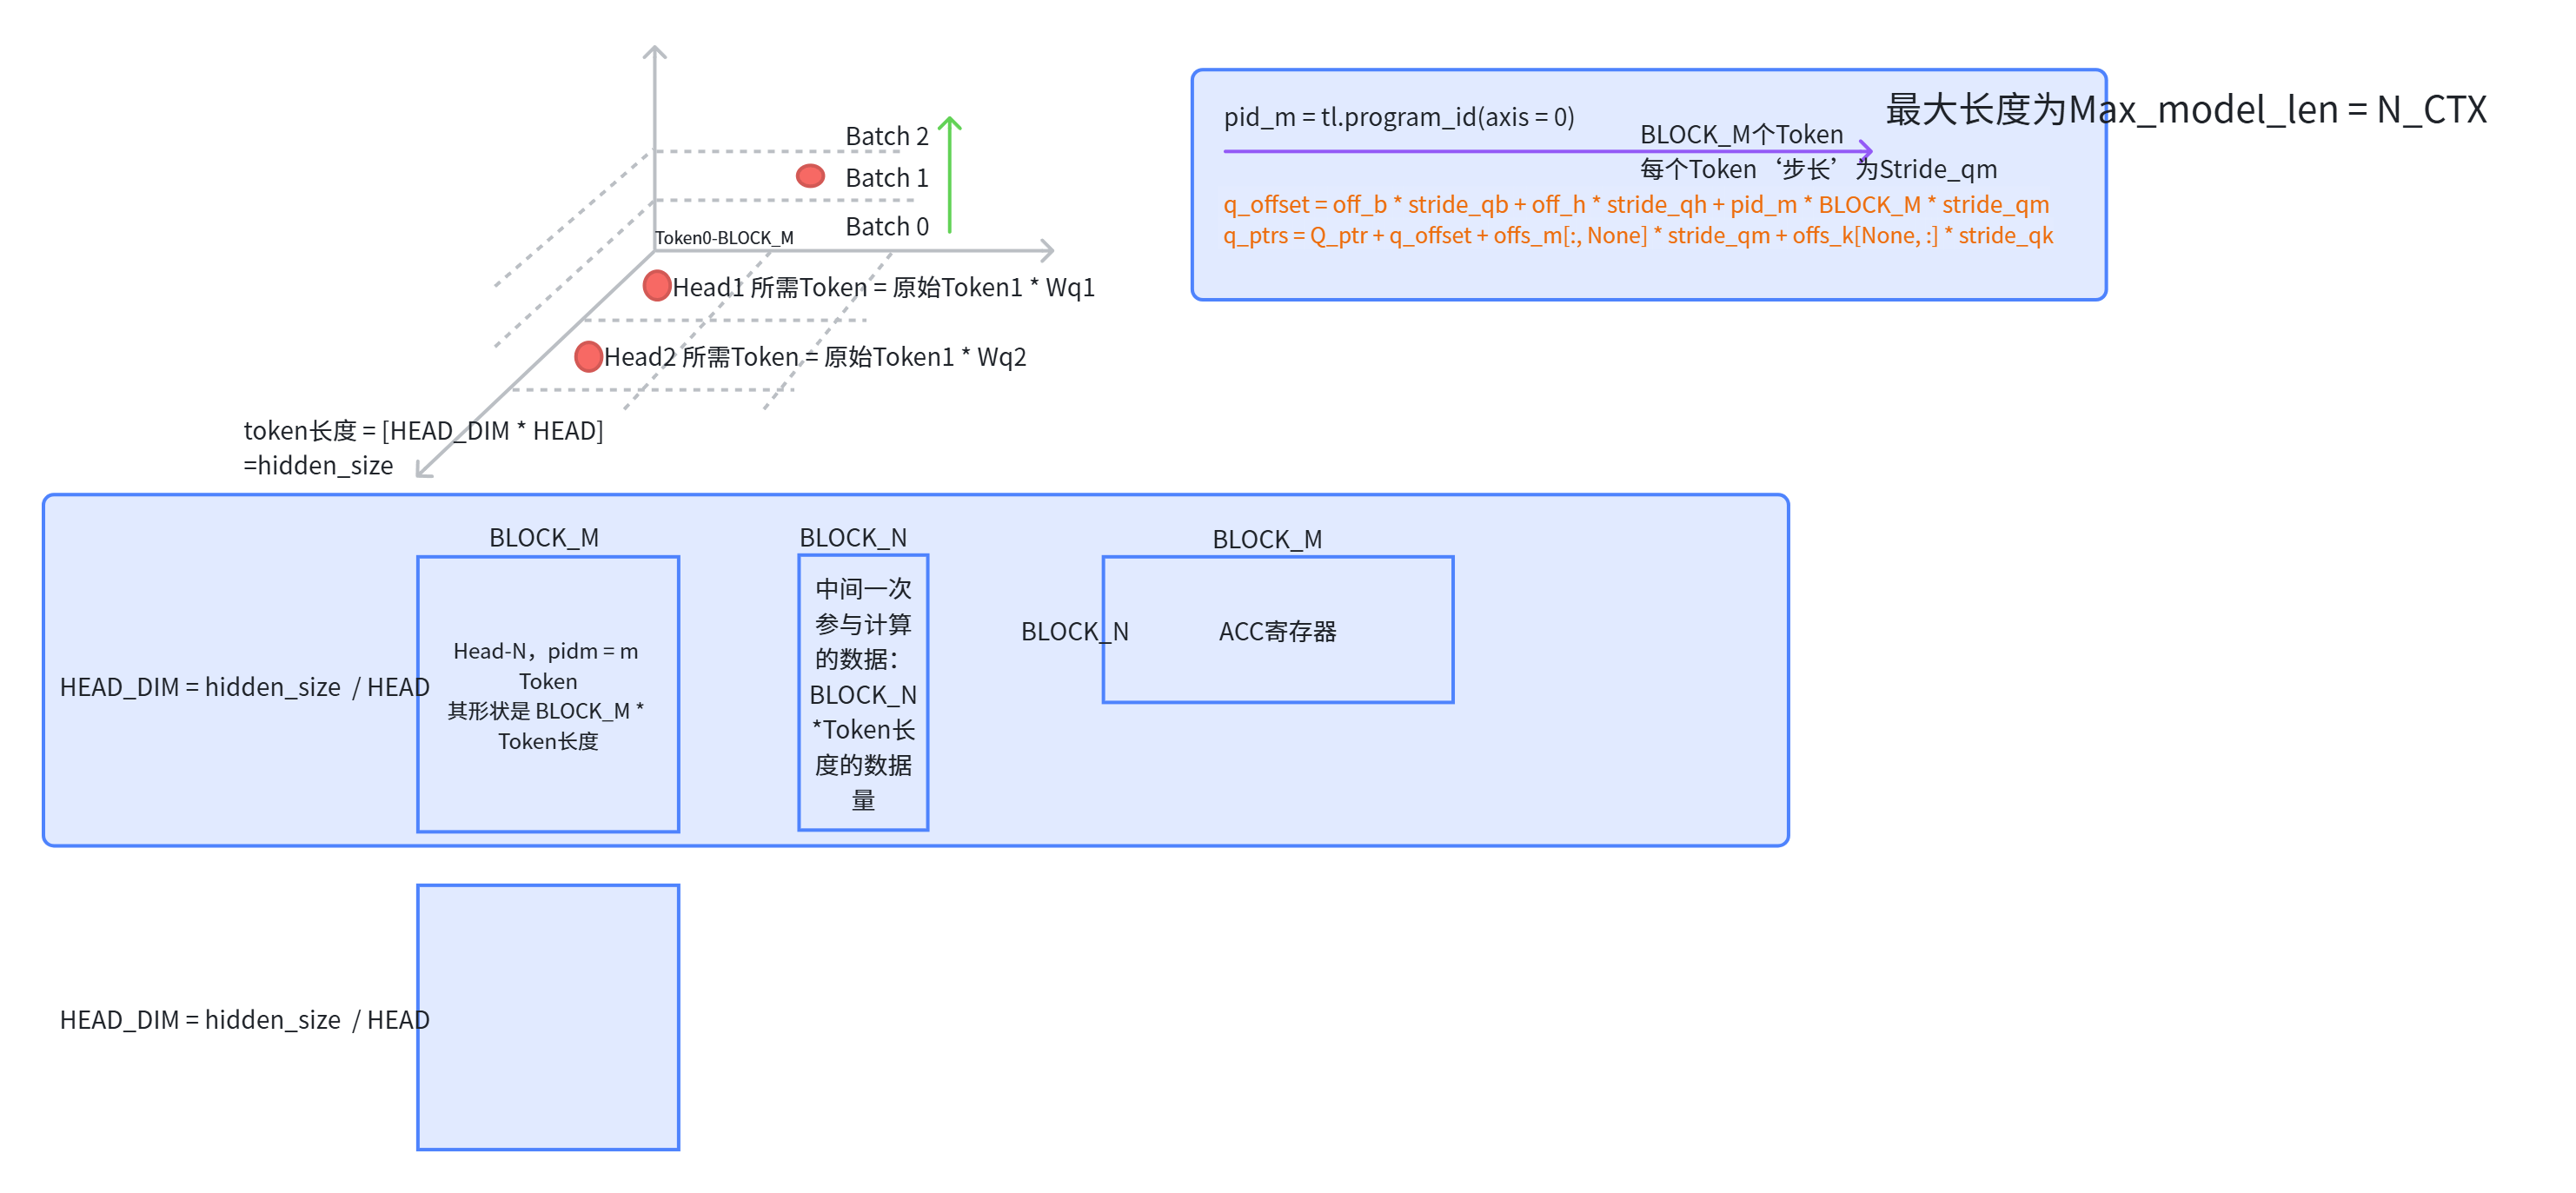

In [25]:
@triton.jit
def _flash_attn_v1_fwd_kernel(
    Q_ptr, K_ptr, V_ptr, O_ptr,
    # 分别对应 QKV以及输出指针
    softmax_scale_log2e,                # softmax_scale * log2(e), 预乘
    
    stride_qb, stride_qh, stride_qm, stride_qd,
    stride_kb, stride_kh, stride_kn, stride_kd,
    stride_vb, stride_vh, stride_vn, stride_vd,
    stride_ob, stride_oh, stride_om, stride_od,
    N_CTX: tl.constexpr,                # 序列长度  = MAX_MODEL_LEN
    HEAD_DIM: tl.constexpr,             # head 维度 (constexpr, 必须是 2 的幂)=隐藏层Hidden_size / Head
    BLOCK_M: tl.constexpr,              # Q 块大小
    BLOCK_N: tl.constexpr,              # KV 块大小 BLOCK_N 个Token
    CAUSAL: tl.constexpr,               # True=causal, False=non-causal
    DTYPE: tl.constexpr,                # 0=fp16, 1=bf16
):
    pid_m = tl.program_id(axis = 0)
    off_h = tl.program_id(axis = 1)
    off_b = tl.program_id(axis = 2)
    
    q_offset = off_b*stride_qb + off_h*stride_qh 
    o_offset = off_b*stride_ob + off_h*stride_oh 
    kv_offset = off_b*stride_kb + off_h*stride_kh 

    offs_m = pid_m * BLOCK_M + tl.arange(0,BLOCK_M)
    offs_d = tl.arange(0,HEAD_DIM)
    # HEAD 注意力头Token所需区域 [0,HEAD_DIM][HEAD_DIM,2*HEAD_DIM][...][...]... = max_model_len 

    Q_ptrs = Q_ptr + q_offset + offs_m[:,None]*stride_qm + offs_d[None,:]*stride_qd
    q = tl.load(Q_ptrs,mask = offs_m[:,None] < N_CTX ,other = 0.0)
    # 加载Q到SRAM
    # OnlineSoftmax
    m_i = tl.full((BLOCK_M,), -float("inf"), dtype=tl.float32)         # 1D
    l_i = tl.zeros((BLOCK_M,), dtype=tl.float32)                       # 1D
    acc = tl.zeros((BLOCK_M, HEAD_DIM), dtype=tl.float32)              # 2D
    if CAUSAL:
        hi_M = (pid_m + 1)* BLOCK_M
    else :
        hi_M = N_CTX
    hi_M = min(hi_M, N_CTX)
    # 因果注意力机制和全注意力机制 决定 K取出数据的上限
    # Q 取出 (BLOCK_M,HEAD_DIM) 大小的数据 KV 每次取出 (BLOCK_N,HEAD_DIM)大小的数据

    for start_n_M in range(0,hi_M,BLOCK_N):
        offs_n = start_n_M + tl.arange(0,BLOCK_N)
        k_ptrs = (K_ptr + kv_offset
                 + offs_n[:,None] * stride_kn
                 + offs_d[None,:] * stride_kd)
        if not CAUSAL :
            k = tl.load(k_ptrs,mask = offs_n[:,None]< N_CTX,other = 0.0)
        else :
            # k = tl.load(k_ptrs,other = 0.0)
            k = tl.load(k_ptrs)
            
        v_ptrs = (V_ptr + kv_offset
                  + offs_n[:, None] * stride_vn
                  + offs_d[None, :] * stride_vd)
        if not CAUSAL:
            v = tl.load(v_ptrs, mask=offs_n[:, None] < N_CTX, other=0.0)
        else:
            v = tl.load(v_ptrs)
        qk = tl.dot(q,tl.trans(k)) * softmax_scale_log2e # (BLOCK_M, BLOCK_N)

        if CAUSAL:
            # 如果是因果注意力机制，需要取下三角区域。
            # 下三角: query_idx >= key_idx 才保留
            causal_mask = offs_m[:, None] >= offs_n[None, :]
            qk = tl.where(causal_mask, qk, -float("inf"))

        #之后对QK进行softmax
        m_ij = tl.max(qk, axis=1)
        m_new = tl.maximum(m_i, m_ij)
        alpha = tl.math.exp2(m_i - m_new)
        p = tl.math.exp2(qk - m_new[:, None])
        l_i = l_i * alpha + tl.sum(p, axis=1)
        acc = acc * alpha[:, None] 
        
        if DTYPE == 0:
            p_typed = p.to(tl.float16)
        else:
            p_typed = p.to(tl.bfloat16)
        acc = tl.dot(p_typed, v, acc)
        m_i = m_new
    # 最后的除法 不再循环中做除法运算了
    acc = acc / l_i[:, None]
    o_ptrs = (O_ptr + o_offset
          + offs_m[:, None] * stride_om
          + offs_d[None, :] * stride_od)
    if DTYPE == 0:
        o_typed = acc.to(tl.float16)
    else:
        o_typed = acc.to(tl.bfloat16)
    tl.store(o_ptrs, o_typed, mask=offs_m[:, None] < N_CTX)

In [18]:
def flash_attention_v1(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    causal: bool = False,
    softmax_scale: Optional[float] = None,
) -> torch.Tensor:

    """
    FlashAttention V1 (Forward only).
    Args:
        q: Query tensor, shape (B, H, N, D), dtype fp16/bf16, contiguous
        k: Key tensor,   shape (B, H, N, D), dtype fp16/bf16, contiguous
        v: Value tensor, shape (B, H, N, D), dtype fp16/bf16, contiguous
        causal: 是否使用 causal mask
        softmax_scale: attention scale, 默认 1/sqrt(D)
    Returns:
        output: shape (B, H, N, D), dtype 与输入一致
    Notes:
        - HEAD_DIM 必须是 2 的幂 (16, 32, 64, 128, 256)
        - 不支持 GQA (假设 H_q == H_kv)
        - 不支持 varlen / packed seq
    """

    # --- 输入检查 ---
    assert q.is_cuda, "q must be on CUDA"
    assert k.is_cuda, "k must be on CUDA"
    assert v.is_cuda, "v must be on CUDA"
    assert q.dtype in (torch.float16, torch.bfloat16), \
        f"q dtype must be fp16 or bf16, got {q.dtype}"
    assert k.dtype == q.dtype and v.dtype == q.dtype, \
        "q, k, v must have the same dtype"
    assert q.is_contiguous(), "q must be contiguous (B, H, N, D)"
    assert k.is_contiguous(), "k must be contiguous (B, H, N, D)"
    assert v.is_contiguous(), "v must be contiguous (B, H, N, D)"
    B, H, N_CTX, HEAD_DIM = q.shape
    assert k.shape == (B, H, N_CTX, HEAD_DIM), \
        f"k shape mismatch: expected {(B, H, N_CTX, HEAD_DIM)}, got {tuple(k.shape)}"
    assert v.shape == (B, H, N_CTX, HEAD_DIM), \
        f"v shape mismatch: expected {(B, H, N_CTX, HEAD_DIM)}, got {tuple(v.shape)}"
    assert HEAD_DIM in (16, 32, 64, 128, 256), \
        f"HEAD_DIM must be power of 2 in (16, 32, 64, 128, 256), got {HEAD_DIM}"
    if softmax_scale is None:
        softmax_scale = 1.0 / math.sqrt(HEAD_DIM)
    # 预乘 log2(e) 用于 exp2 优化
    softmax_scale_log2e = softmax_scale * LOG2E
    # 分配输出
    o = torch.empty_like(q)

    # Block size 选择 (生产环境应该用 autotune, 这里给个合理的 default)
    # 经验值: BLOCK_M 越大, Q 块越多, 算力利用率越高
    #        BLOCK_N 越小, SRAM 压力小, 但循环次数多
    BLOCK_M = 128 if N_CTX >= 512 else 64
    BLOCK_N = 64 if HEAD_DIM <= 64 else 32
    # Grid: (Q 块数, H, B)
    grid = (triton.cdiv(N_CTX, BLOCK_M), H, B)
    _flash_attn_v1_fwd_kernel[grid](
        q, k, v, o,
        softmax_scale_log2e,
        q.stride(0), q.stride(1), q.stride(2), q.stride(3),
        k.stride(0), k.stride(1), k.stride(2), k.stride(3),
        v.stride(0), v.stride(1), v.stride(2), v.stride(3),
        o.stride(0), o.stride(1), o.stride(2), o.stride(3),
        N_CTX=N_CTX,
        HEAD_DIM=HEAD_DIM,
        BLOCK_M=BLOCK_M,
        BLOCK_N=BLOCK_N,
        CAUSAL=causal,
        DTYPE=0 if q.dtype == torch.float16 else 1,
    )

    return o

In [19]:
# =============================================================================

# 参考实现 (PyTorch) - 用于验证

# =============================================================================

def reference_attention(

    q: torch.Tensor,

    k: torch.Tensor,

    v: torch.Tensor,

    causal: bool = False,

    softmax_scale: Optional[float] = None,

) -> torch.Tensor:

    """标准 PyTorch attention, 作为 ground truth."""

    B, H, N, D = q.shape

    if softmax_scale is None:

        softmax_scale = 1.0 / math.sqrt(D)


    qk = torch.matmul(q, k.transpose(-2, -1)) * softmax_scale   # (B, H, N, N)


    if causal:

        # 下三角 mask: query_idx >= key_idx

        mask = torch.tril(torch.ones(N, N, device=q.device, dtype=torch.bool))

        qk = qk.masked_fill(~mask, float("-inf"))


    p = torch.softmax(qk, dim=-1)                                # (B, H, N, N)

    return torch.matmul(p, v)                                    # (B, H, N, D)



# =============================================================================

# 验证 + Benchmark

# =============================================================================

def verify(B: int = 2, H: int = 4, N: int = 256, D: int = 64,

           dtype: torch.dtype = torch.float16, causal: bool = True):

    """正确性验证: Triton vs PyTorch."""

    torch.manual_seed(0)

    device = "cuda"


    q = torch.randn(B, H, N, D, device=device, dtype=dtype)

    k = torch.randn(B, H, N, D, device=device, dtype=dtype)

    v = torch.randn(B, H, N, D, device=device, dtype=dtype)


    out = flash_attention_v1(q, k, v, causal=causal)

    ref = reference_attention(q, k, v, causal=causal)


    max_abs_err = (out.float() - ref.float()).abs().max().item()

    max_rel_err = ((out.float() - ref.float()).abs()

                   / (ref.float().abs() + 1e-6)).max().item()

    print(f"[verify] max abs err = {max_abs_err:.4e}, "

          f"max rel err = {max_rel_err:.4e}")


    # fp16 下绝对误差 < 5e-3 算通过

    if max_abs_err < 5e-3:

        print(f"[verify] ✅ Passed (causal={causal}, dtype={dtype})")

        return True

    else:

        print(f"[verify] ❌ Failed (causal={causal}, dtype={dtype})")

        return False

In [20]:

def benchmark(B: int = 4, H: int = 16, N: int = 4096, D: int = 128,

              dtype: torch.dtype = torch.float16):

    """性能 benchmark."""

    import time

    device = "cuda"


    q = torch.randn(B, H, N, D, device=device, dtype=dtype)

    k = torch.randn(B, H, N, D, device=device, dtype=dtype)

    v = torch.randn(B, H, N, D, device=device, dtype=dtype)


    flops = 4 * B * H * N * N * D / 1e9   # GFLOPs

    print(f"\n[bench] B={B}, H={H}, N={N}, D={D}, dtype={dtype}")

    print(f"[bench] FLOPs per iter: {flops:.2f} GFLOPs")
    for causal in [False, True]:
        # Warmup
        for _ in range(3):
            _ = flash_attention_v1(q, k, v, causal=causal)
        torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(10):
            _ = flash_attention_v1(q, k, v, causal=causal)
        torch.cuda.synchronize()
        t_flash = (time.time() - t0) / 10 * 1e3  # ms
        # 参考实现
        for _ in range(3):
            _ = reference_attention(q, k, v, causal=causal)
        torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(10):
            _ = reference_attention(q, k, v, causal=causal)
        torch.cuda.synchronize()
        t_ref = (time.time() - t0) / 10 * 1e3
        tflops_flash = flops / t_flash
        tflops_ref = flops / t_ref
        print(f"[bench] causal={causal:5}: "
              f"flash={t_flash:6.2f} ms ({tflops_flash:5.1f} TFLOPs), "
              f"ref={t_ref:6.2f} ms ({tflops_ref:5.1f} TFLOPs), "
              f"speedup={t_ref / t_flash:.2f}x")

In [26]:
print("=" * 60)
print("FlashAttention V1 (Production) - 验证 + Benchmark")
print("=" * 60)
# 正确性验证
print("\n--- 正确性验证 ---")

verify(B=2, H=4, N=128, D=64, dtype=torch.float16, causal=False)
verify(B=2, H=4, N=128, D=64, dtype=torch.float16, causal=True)
verify(B=2, H=4, N=128, D=64, dtype=torch.bfloat16, causal=False)
verify(B=2, H=4, N=128, D=64, dtype=torch.bfloat16, causal=True)

# 性能 benchmark
print("\n--- 性能 benchmark ---")
if torch.cuda.is_available():
    benchmark(B=4, H=16, N=2048, D=128, dtype=torch.float16)
else:
    print("[bench] CUDA not available, skip benchmark")

FlashAttention V1 (Production) - 验证 + Benchmark

--- 正确性验证 ---
[verify] max abs err = 9.7656e-04, max rel err = 8.2002e+00
[verify] ✅ Passed (causal=False, dtype=torch.float16)
[verify] max abs err = 1.9531e-03, max rel err = 3.1099e+01
[verify] ✅ Passed (causal=True, dtype=torch.float16)
[verify] max abs err = 7.8125e-03, max rel err = 3.4691e+02
[verify] ❌ Failed (causal=False, dtype=torch.bfloat16)
[verify] max abs err = 1.5625e-02, max rel err = 3.3922e+02
[verify] ❌ Failed (causal=True, dtype=torch.bfloat16)

--- 性能 benchmark ---

[bench] B=4, H=16, N=2048, D=128, dtype=torch.float16
[bench] FLOPs per iter: 137.44 GFLOPs
[bench] causal=    0: flash=  6.30 ms ( 21.8 TFLOPs), ref= 14.85 ms (  9.3 TFLOPs), speedup=2.36x
[bench] causal=    1: flash=  3.45 ms ( 39.9 TFLOPs), ref= 23.14 ms (  5.9 TFLOPs), speedup=6.72x
